# Advanced Image Classification with ImageNet

In this assignment, you will be asked to develop a convolutional neural network (CNN) to classify images from the CIFAR-100 dataset. At each step, you'll be guided through the process of developing a model architecture to solve a problem. Your goal is to create a CNN that attains at least 55% accuracy on the validation set.

### The CIFAR-100 Dataset

The [CIFAR-100 dataset](https://www.cs.toronto.edu/~kriz/cifar.html) consists of 60000 32x32 colour images in 100 classes, with 600 images per class. There are 50000 training images and 10000 test images. The dataset is divided into five training batches and one test batch, each with 10000 images. The test batch contains exactly 1000 randomly-selected images from each class. The training batches contain the remaining images in random order, but some training batches may contain more images from one class than another. Between them, the training batches contain exactly 500 images from each class.

### Tools

You will use Keras with TensorFlow to develop your CNN. For this assignment, it's strongly recommended that you use a GPU to accelerate your training, or else you might find it difficult to train your network in a reasonable amount of time. If you have a computer with a GPU that you wish to use, you can follow the [TensorFlow instructions](https://www.tensorflow.org/install/) for installing TensorFlow with GPU support. Otherwise, you can use [Google Colab](https://colab.research.google.com/) to complete this assignment. Colab provides free access to GPU-enabled machines. If you run into any issues, please contact us as soon as possible so that we can help you resolve them.

## Task 1: Data Exploration and Preprocessing (Complete or Incomplete)
### 1a: Load and Explore the Dataset
- Use the code below to download the dataset.
- Explore the dataset: examine the shape of the training and test sets, the dimensions of the images, and the number of classes. Show a few examples from the training set.

In [1]:
from keras.datasets import cifar100

# Load the CIFAR-100 dataset
(x_train, y_train), (x_test, y_test) = cifar100.load_data(label_mode='fine')

169001437/169001437 [==============================] - 17s 0us/step


In [2]:
class_names = [
    "apple", "aquarium_fish", "baby", "bear", "beaver", "bed", "bee", "beetle", "bicycle", "bottle",
    "bowl", "boy", "bridge", "bus", "butterfly", "camel", "can", "castle", "caterpillar", "cattle",
    "chair", "chimpanzee", "clock", "cloud", "cockroach", "couch", "crab", "crocodile", "cup", "dinosaur",
    "dolphin", "elephant", "flatfish", "forest", "fox", "girl", "hamster", "house", "kangaroo", "keyboard",
    "lamp", "lawn_mower", "leopard", "lion", "lizard", "lobster", "man", "maple_tree", "motorcycle", "mountain",
    "mouse", "mushroom", "oak_tree", "orange", "orchid", "otter", "palm_tree", "pear", "pickup_truck", "pine_tree",
    "plain", "plate", "poppy", "porcupine", "possum", "rabbit", "raccoon", "ray", "road", "rocket",
    "rose", "sea", "seal", "shark", "shrew", "skunk", "skyscraper", "snail", "snake", "spider",
    "squirrel", "streetcar", "sunflower", "sweet_pepper", "table", "tank", "telephone", "television", "tiger", "tractor",
    "train", "trout", "tulip", "turtle", "wardrobe", "whale", "willow_tree", "wolf", "woman", "worm"
]

Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Test data shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)
Number of classes: 100


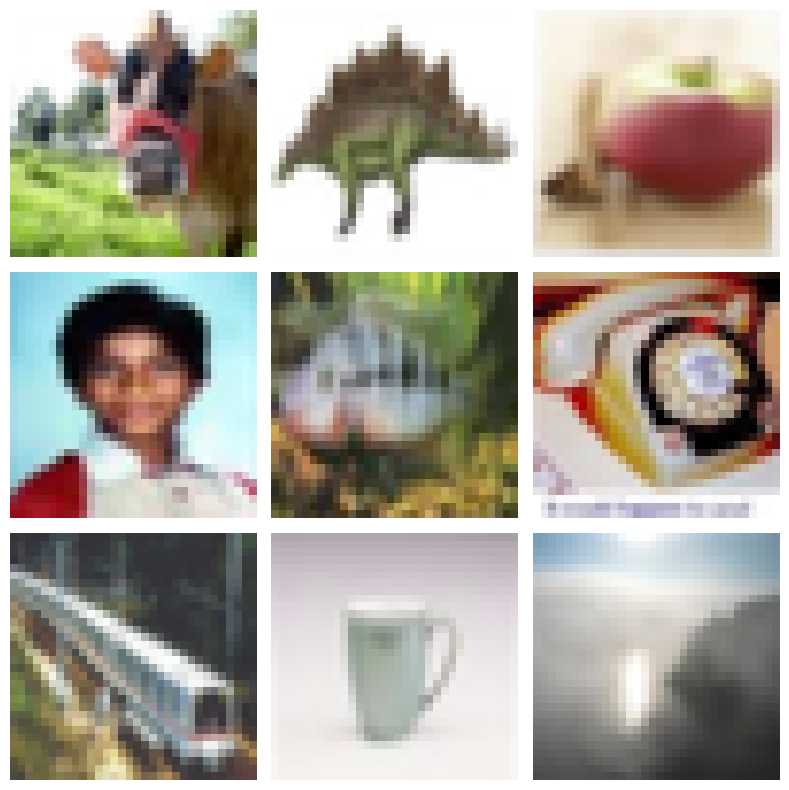

In [3]:
import numpy as np
import matplotlib.pyplot as plt

print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test data shape:", x_test.shape)
print("Test labels shape:", y_test.shape)

num_classes = 100
print("Number of classes:", num_classes)

plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(x_train[i])
    plt.axis('off')
plt.tight_layout()
plt.show()


### 1b: Data Preprocessing
- With the data downloaded, it's time to preprocess it. Start by normalizing the images so that they all have pixel values in the range [0, 1].
- Next, convert the labels to one-hot encoded vectors.
- Finally, split the training set into training and validation sets. Use 80% of the training set for training and the remaining 20% for validation.

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

y_train_onehot = to_categorical(y_train, num_classes)
y_test_onehot  = to_categorical(y_test, num_classes)

x_train_part, x_val, y_train_part, y_val = train_test_split(
    x_train, y_train_onehot, test_size=0.2, random_state=42
)

print("Training set shape after split:", x_train_part.shape)
print("Validation set shape:", x_val.shape)


Training set shape after split: (40000, 32, 32, 3)
Validation set shape: (10000, 32, 32, 3)


## Task 2: Model Development (Complete or Incomplete)
### Task 2a: Create a Baseline CNN Model
- Design a CNN architecture. Your architecture should use convolutional layers, max pooling layers, and dense layers. You can use any number of layers, and you can experiment with different numbers of filters, filter sizes, strides, padding, etc. The design doesn't need to be perfect, but it should be unique to you.
- Print out the model summary.

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.layers import Activation

model = Sequential()

# Convolution Block 1
model.add(Conv2D(32, (3, 3), padding='same', input_shape=(32, 32, 3)))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# Convolution Block 2
model.add(Conv2D(64, (3, 3), padding='same'))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# Convolution Block 3
model.add(Conv2D(128, (3, 3), padding='same'))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten and Dense Layers
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))  # Regularization
model.add(Dense(100, activation='softmax'))

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 32)        896       
                                                                 
 activation (Activation)     (None, 32, 32, 32)        0         
                                                                 
 batch_normalization (BatchN  (None, 32, 32, 32)       128       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 16, 16, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 16, 16, 64)        18496     
                                                                 
 activation_1 (Activation)   (None, 16, 16, 64)        0

### Task 2b: Compile the model

- Select an appropriate loss function and optimizer for your model. These can be ones we have looked at already, or they can be different. 
- Briefly explain your choices (one or two sentences each).
- <b>Loss function:</b> ______
- <b>Optimizer:</b> ______

In [6]:
from tensorflow.keras.optimizers import Adam

# Compile
model.compile(
    loss='categorical_crossentropy', 
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)


## Task 3: Model Training and Evaluation (Complete or Incomplete)
### Task 3a: Train the Model

- Train your model for an appropriate number of epochs. Explain your choice of the number of epochs used - you can change this number before submitting your assignment.
- Use a batch size of 32.
- Use the validation set for validation.

In [7]:
epochs = 20  
batch_size = 32

history = model.fit(
    x_train_part, y_train_part,
    validation_data=(x_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)


Epoch 1/20
1250/1250 [==============================] - 29s 22ms/step - loss: 3.9940 - accuracy: 0.0952 - val_loss: 3.6139 - val_accuracy: 0.1496
Epoch 2/20
1250/1250 [==============================] - 27s 22ms/step - loss: 3.3695 - accuracy: 0.1832 - val_loss: 3.0924 - val_accuracy: 0.2373
Epoch 3/20
1250/1250 [==============================] - 27s 22ms/step - loss: 3.0383 - accuracy: 0.2412 - val_loss: 3.8783 - val_accuracy: 0.1819
Epoch 4/20
1250/1250 [==============================] - 28s 22ms/step - loss: 2.8139 - accuracy: 0.2851 - val_loss: 2.9096 - val_accuracy: 0.2775
Epoch 5/20
1250/1250 [==============================] - 27s 22ms/step - loss: 2.6176 - accuracy: 0.3246 - val_loss: 2.6492 - val_accuracy: 0.3266
Epoch 6/20
1250/1250 [==============================] - 29s 23ms/step - loss: 2.4269 - accuracy: 0.3600 - val_loss: 2.5103 - val_accuracy: 0.3596
Epoch 7/20
1250/1250 [==============================] - 27s 22ms/step - loss: 2.2610 - accuracy: 0.3995 - val_loss: 2.4793 -

### Task 3b: Accuracy and other relevant metrics on the test set

- Report the accuracy of your model on the test set.
- While accuracy is a good metric, there are many other ways to numerically evaluate a model. Report at least one other metric, and explain what it measures and how it is calculated.

- <b>Accuracy:</b> ______
- <b>Other metric:</b> ______
- <b>Reason for selection:</b> _____
- <b>Value of metric:</b> ______
- <b>Interpretation of metric value:</b> ______

In [8]:

test_loss, test_accuracy = model.evaluate(x_test, y_test_onehot, verbose=0)
print("Test Accuracy:", round(test_accuracy * 100, 2), "%")
print("Test Loss:", round(test_loss, 3))


Test Accuracy: 41.73 %
Test Loss: 3.009


In [9]:
from sklearn.metrics import classification_report

y_pred_proba = model.predict(x_test)            # Probabilities
y_pred = np.argmax(y_pred_proba, axis=1)        # Predicted class labels
y_true = np.argmax(y_test_onehot, axis=1)       # True class labels

report = classification_report(y_true, y_pred, output_dict=True)
f1_macro = report['macro avg']['f1-score']
print("F1-score (macro):", round(f1_macro, 3))


313/313 [==============================] - 3s 8ms/step
F1-score (macro): 0.417


### Task 3c: Visualize the model's learning

- Plot the training accuracy and validation accuracy with respect to epochs.
- Select an image that the model correctly classified in the test set, and an image that the model incorrectly classified in the test set. Plot the images and report the model's classification probabilities for each.
- Briefly discuss the results. What do the plots show? Do the results make sense? What do the classification probabilities indicate?

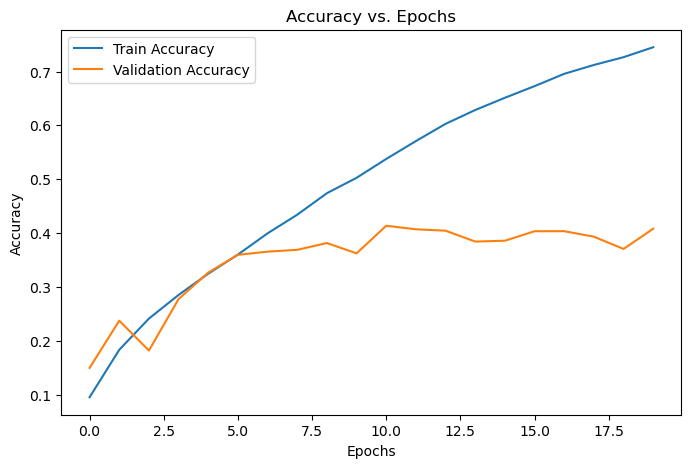

1/1 [==============================] - 0s 23ms/step
Correctly Classified Example:


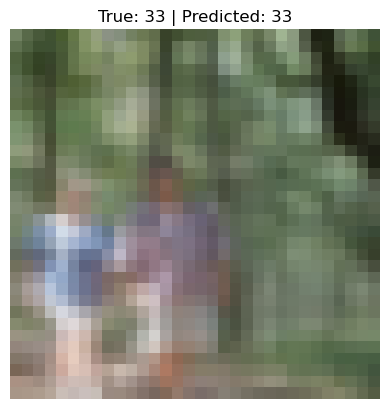

Top 5 predicted classes and probabilities:
Class 33: 0.8527
Class 59: 0.0881
Class 96: 0.0377
Class 88: 0.0130
Class 8: 0.0018

Incorrectly Classified Example:


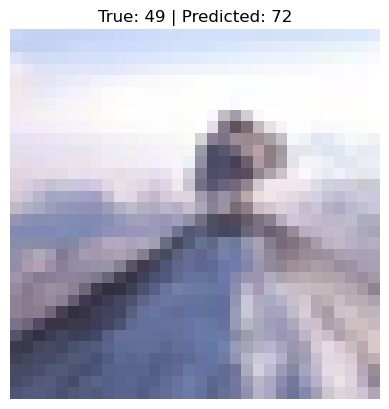

Top 5 predicted classes and probabilities:
Class 72: 0.2890
Class 30: 0.1664
Class 49: 0.1187
Class 95: 0.0993
Class 76: 0.0669


In [10]:
# Plot training vs validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Pick an image that the model correctly classified
correct_index = None
incorrect_index = None

for i in range(len(x_test)):
    pred_label = np.argmax(model.predict(x_test[i:i+1]))
    true_label = np.argmax(y_test_onehot[i])
    if pred_label == true_label and correct_index is None:
        correct_index = i
    if pred_label != true_label and incorrect_index is None:
        incorrect_index = i
    if correct_index is not None and incorrect_index is not None:
        break

def show_classification_details(index):
    plt.imshow(x_test[index])
    plt.title("True: {} | Predicted: {}".format(y_true[index], y_pred[index]))
    plt.axis('off')
    plt.show()
    
    # Show classification probabilities
    probs = y_pred_proba[index]
    top5_indices = probs.argsort()[-5:][::-1]
    print("Top 5 predicted classes and probabilities:")
    for idx in top5_indices:
        print(f"Class {idx}: {probs[idx]:.4f}")

print("Correctly Classified Example:")
show_classification_details(correct_index)

print("\nIncorrectly Classified Example:")
show_classification_details(incorrect_index)


## Task 4: Model Enhancement (Complete or Incomplete)
### Task 4a: Implementation of at least one advanced technique

- Now it's time to improve your model. Implement at least one technique to improve your model's performance. You can use any of the techniques we have covered in class, or you can use a technique that we haven't covered. If you need inspiration, you can refer to the [Keras documentation](https://keras.io/).
- Explain the technique you used and why you chose it.
- If you used a technique that requires tuning, explain how you selected the values for the hyperparameters.

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create an ImageDataGenerator with data augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

# Re-initialize / re-create the same model architecture
model_enhanced = Sequential()
model_enhanced.add(Conv2D(32, (3, 3), padding='same', input_shape=(32, 32, 3)))
model_enhanced.add(Activation('relu'))
model_enhanced.add(BatchNormalization())
model_enhanced.add(MaxPooling2D(pool_size=(2, 2)))

model_enhanced.add(Conv2D(64, (3, 3), padding='same'))
model_enhanced.add(Activation('relu'))
model_enhanced.add(BatchNormalization())
model_enhanced.add(MaxPooling2D(pool_size=(2, 2)))

model_enhanced.add(Conv2D(128, (3, 3), padding='same'))
model_enhanced.add(Activation('relu'))
model_enhanced.add(BatchNormalization())
model_enhanced.add(MaxPooling2D(pool_size=(2, 2)))

model_enhanced.add(Flatten())
model_enhanced.add(Dense(256, activation='relu'))
model_enhanced.add(Dropout(0.3))
model_enhanced.add(Dense(100, activation='softmax'))

model_enhanced.compile(
    loss='categorical_crossentropy', 
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)





Data augmentation artificially expands the training set by applying random transformations (e.g. flips, shifts).
This helps reduce overfitting and can improve generalization.

### Task 4b: Evaluation of the enhanced model

- Re-train your model using the same number of epochs as before.
- Compare the accuracy and other selected metric on the test set to the results you obtained before.
- As before, plot the training accuracy and validation accuracy with respect to epochs, and select an image that the model correctly classified in the test set, and an image that the model incorrectly classified in the test set. Plot the images and report the model's classification probabilities for each.

Epoch 1/20
1250/1250 [==============================] - 59s 46ms/step - loss: 4.0953 - accuracy: 0.0820 - val_loss: 3.5723 - val_accuracy: 0.1466
Epoch 2/20
1250/1250 [==============================] - 56s 45ms/step - loss: 3.5919 - accuracy: 0.1463 - val_loss: 3.2175 - val_accuracy: 0.2134
Epoch 3/20
1250/1250 [==============================] - 54s 43ms/step - loss: 3.3234 - accuracy: 0.1938 - val_loss: 3.2778 - val_accuracy: 0.2125
Epoch 4/20
1250/1250 [==============================] - 58s 47ms/step - loss: 3.1441 - accuracy: 0.2236 - val_loss: 2.9680 - val_accuracy: 0.2608
Epoch 5/20
1250/1250 [==============================] - 56s 45ms/step - loss: 3.0178 - accuracy: 0.2476 - val_loss: 2.7321 - val_accuracy: 0.3085
Epoch 6/20
1250/1250 [==============================] - 74s 59ms/step - loss: 2.8921 - accuracy: 0.2718 - val_loss: 2.6633 - val_accuracy: 0.3246
Epoch 7/20
1250/1250 [==============================] - 81s 65ms/step - loss: 2.7906 - accuracy: 0.2932 - val_loss: 2.5788 -

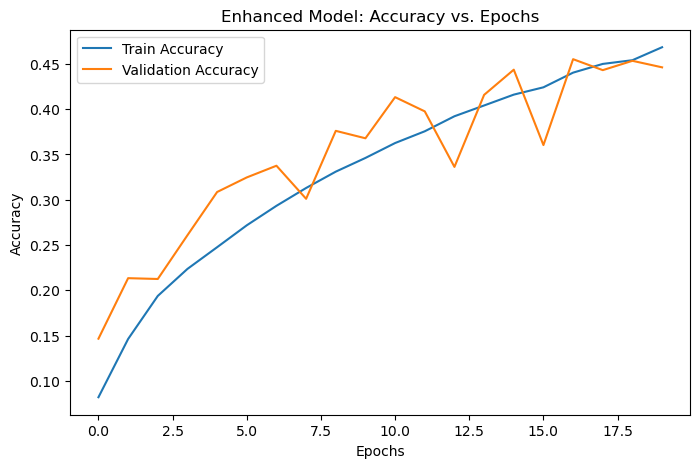

In [12]:
epochs = 20
batch_size = 32

# Fit the model using the augmented data generator
history_enhanced = model_enhanced.fit(
    datagen.flow(x_train_part, y_train_part, batch_size=batch_size),
    epochs=epochs,
    validation_data=(x_val, y_val),
    steps_per_epoch=len(x_train_part) // batch_size,
    verbose=1
)

# Evaluate on the test set
test_loss_enhanced, test_acc_enhanced = model_enhanced.evaluate(x_test, y_test_onehot, verbose=0)
print("Enhanced Model Test Accuracy:", round(test_acc_enhanced * 100, 2), "%")

y_pred_enhanced_proba = model_enhanced.predict(x_test)
y_pred_enhanced = np.argmax(y_pred_enhanced_proba, axis=1)
report_enhanced = classification_report(y_true, y_pred_enhanced, output_dict=True)
f1_macro_enhanced = report_enhanced['macro avg']['f1-score']
print("Enhanced Model F1-score (macro):", round(f1_macro_enhanced, 3))

# Plot training vs validation accuracy for enhanced model
plt.figure(figsize=(8, 5))
plt.plot(history_enhanced.history['accuracy'], label='Train Accuracy')
plt.plot(history_enhanced.history['val_accuracy'], label='Validation Accuracy')
plt.title('Enhanced Model: Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


### Task 4c: Discussion of the results

- Briefly discuss the results. 
- Did the model's performance improve? 
- Why do you think this is?
- Do you think there is room for further improvement? Why or why not?
- What other techniques might you try in the future?
- Your answer should be no more than 200 words.

# Your answer here

## Criteria

|Criteria|Complete|Incomplete|
|----|----|----|
|Task 1|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 2|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 3|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 4|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-3-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.